In [168]:
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils import spectral_norm
import torch.nn.functional as F

from tqdm import tqdm

import segmentation_models_pytorch as smp

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split 

import albumentations as TA
import seaborn as sns, matplotlib.pyplot as plt

# Constants

In [ ]:
DEVICE  = torch.device(f"cuda:0" if torch.cuda.is_available() else "cpu")
#DEVICE  = "cpu"
print(DEVICE)

In [ ]:
CROP_IDS = [-1, 1, 2, 3, 4, 5, 6, 7, 8, 9]
CROP_CLASSES = ["No data", "Wheat", "Rye", "Barley", "Oats", "Corn", "Oil Seeds", "Root Crops",
                "Meadows", "Forage Crops"]
NUM_CLASSES = 10
EPOCHS = 50


In [ ]:
base_path = "../Dataset"

dataset = base_path + "/s2-utm-33N-18E-242N-2018"
train_geojson_path = base_path + "/br-18E-242N-crop-labels-train-2018.geojson"

folder = "/DS3"
subfolder1 = "/Temporal Data"

data_path = dataset+folder
temporal_data_path = dataset+folder+subfolder1

classification_model_path = "../Classification models/Spatial"
temporal_classification_model_path = "../Classification models/Temporal"


# Helper functions

In [ ]:
class ImageLabelDataset(Dataset):
    def __init__(self, image_array, label_array):
        self.images = torch.tensor(image_array, dtype=torch.float32)  # (N, 4, 64, 64)
        self.labels = torch.tensor(label_array, dtype=torch.float32)  # (N, 1, 64, 64)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]


In [ ]:
def save_models(
    model,
    optimizer,
    scheduler,
    scaler,
    epoch,
    segmentation_model_name,
    encoder_name,
    path
):
    filename = f'/Classification_Model_Pipeline-{segmentation_model_name}_Encoder-{encoder_name}'+r'-Epoch '+str(epoch)+r'.pth'
    full_path = path + filename

    payload = {
        "epochs": int(epoch),
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict(),
    }
    torch.save(payload, full_path)

    print(f"Models saved to {full_path}")

def load_model_cassifier(
    path,
    model,
    optimizer,
    scheduler,
    scaler,
    device="cpu",
):
    """
    Load a training checkpoint. Returns the next epoch index to continue from.
    Loads only what you pass in (model, optimizer, scheduler, scaler).
    """
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint["scheduler_state"])
    scaler.load_state_dict(checkpoint["scaler_state"])

    start_epoch = int(checkpoint.get("epochs"))
    return start_epoch


# Model definations

In [ ]:

# U-Net with ResNet-50 encoder
unet_r50 = smp.Unet(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=4,
    classes=NUM_CLASSES
)

# DeepLabV3+ with ResNet-50
deeplab_r50 = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=4,
    classes=NUM_CLASSES
)

# U-Net with ResNet-101 encoder
unet_r101 = smp.Unet(
    encoder_name="resnet101",
    encoder_weights=None,
    in_channels=4,
    classes=NUM_CLASSES
)

# DeepLabV3+ with ResNet-101
deeplab_r101 = smp.DeepLabV3Plus(
    encoder_name="resnet101",
    encoder_weights=None,
    in_channels=4,
    classes=NUM_CLASSES
)

model_list = [unet_r50, deeplab_r50, unet_r101, deeplab_r101]
model_name_list = ['unet_r50', 'deeplab_r50', 'unet_r101', 'deeplab_r101']
encoder_name_list = ['resnet50', 'resnet101']


### Model data

In [ ]:
model_data = {
    "id": 8,              # Integer value 
    "start_epoch": 10,    # Integer
    "end_epoch": 500,     # Integer
    "depth": 12,          # No of layers,
    "interval": 10,       # Model save frequency in epochs
    "best_model": 110,    # Based on loss curves along with FID and KID scores
    "date": "2025-08-11", # Format: YYYY-MM-DD  # Best model date
}

selected_model_path = "../GAN models/Spatial models/NIR - based/acgan_checkpoint-Model "+ str(model_data["id"]) +"-Epoch "+str(model_data["best_model"])+"_"+model_data["date"]+".pth"


### GAN model

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, dim, heads=4, dim_ff=512, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim_ff),
            nn.GELU(),
            nn.Linear(dim_ff, dim),
        )

    def forward(self, x):
        x_res = x
        x = self.norm1(x)
        x, _ = self.attn(x, x, x)
        x = x + x_res

        x_res = x
        x = self.norm2(x)
        x = self.ff(x) + x_res
        return x
    
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            spectral_norm(nn.Conv2d(channels, channels, 3, padding=1)),
            nn.ReLU(),
            spectral_norm(nn.Conv2d(channels, channels, 3, padding=1)),
        )

    def forward(self, x):
        return x + self.block(x)
    
class UNetTransformerGenerator(nn.Module):
    def __init__(self, in_channels=14, out_channels=4, emb_dim=512, num_heads=8, depth=4):
        super().__init__()

        # Encoder
        self.enc1 = nn.Sequential(
            spectral_norm(nn.Conv2d(in_channels, 64, 3, padding=1)), 
            nn.ReLU(),
            spectral_norm(nn.Conv2d(64, 64, 3, padding=1)), 
            nn.ELU(),
            ResidualBlock(64)
        )
        self.enc2 = nn.Sequential(
            nn.MaxPool2d(2),
            spectral_norm(nn.Conv2d(64, 128, 3, padding=1)),
            nn.GELU(),
            ResidualBlock(128)
        )
        self.enc3 = nn.Sequential(
            nn.MaxPool2d(2),
            spectral_norm(nn.Conv2d(128, 256, 3, padding=1)),
            nn.ReLU(),
            ResidualBlock(256)
        )
        self.enc4 = nn.Sequential(
            nn.MaxPool2d(2),
            spectral_norm(nn.Conv2d(256, emb_dim, 3, padding=1)),  # 512 default
            nn.GELU(),
            ResidualBlock(emb_dim)
        )

        # Transformer
        self.flatten = nn.Flatten(2)
        self.transformers = nn.Sequential(*[
            TransformerBlock(emb_dim, heads=num_heads) for _ in range(depth)
        ])
        self.unflatten = lambda x: x.view(x.size(0), emb_dim, 8, 8)

        # Decoder
        self.dec4 = nn.Sequential(
            ResidualBlock(emb_dim),
            nn.Upsample(scale_factor=2),
            spectral_norm(nn.Conv2d(emb_dim, 256, 3, padding=1)),
            nn.ReLU()
        )
        self.dec3 = nn.Sequential(
            ResidualBlock(512),  # 256 from dec4 + 256 from enc3
            nn.Upsample(scale_factor=2),
            spectral_norm(nn.Conv2d(512, 128, 3, padding=1)),
            nn.ReLU()
        )
        self.dec2 = nn.Sequential(
            ResidualBlock(256),  # 128 + 128
            nn.Upsample(scale_factor=2),
            spectral_norm(nn.Conv2d(256, 64, 3, padding=1)),
            nn.ReLU()
        )
        self.dec1 = nn.Sequential(
            ResidualBlock(128),  # 64 + 64
            spectral_norm(nn.Conv2d(128, out_channels, 3, padding=1)),
            nn.Tanh()
        )

    def forward(self, noise, label_map):
        x = torch.cat([noise, label_map], dim=1)  # [B, 14, 64, 64]

        e1 = self.enc1(x)        # [B, 64, 64, 64]
        e2 = self.enc2(e1)       # [B, 128, 32, 32]
        e3 = self.enc3(e2)       # [B, 256, 16, 16]
        e4 = self.enc4(e3)       # [B, 512, 8, 8]

        x_flat = self.flatten(e4).permute(0, 2, 1)  # [B, 64, 512]
        x_trans = self.transformers(x_flat)
        x_unflat = self.unflatten(x_trans.permute(0, 2, 1))  # [B, 512, 8, 8]

        d4 = self.dec4(x_unflat)                         # [B, 256, 16, 16]
        d3 = self.dec3(torch.cat([d4, e3], dim=1))       # [B, 128, 32, 32]
        d2 = self.dec2(torch.cat([d3, e2], dim=1))       # [B, 64, 64, 64]
        d1 = self.dec1(torch.cat([d2, e1], dim=1))       # [B, out_channels, 64, 64]

        return d1

class DiscriminatorWithLabelEmbedding(nn.Module):
    def __init__(self, in_channels=4, label_classes=10, base_channels=64):
        super().__init__()

        self.img_conv = nn.Sequential(
            nn.Conv2d(in_channels, base_channels, 4, 2, 1),  # [B, 64, 32, 32]
            nn.LeakyReLU(0.2)
        )

        self.label_embed = nn.Sequential(
            nn.Conv2d(label_classes, base_channels, 4, 2, 1),
            nn.LeakyReLU(0.2)
        )

        # Save layers individually to extract features
        self.conv1 = nn.Sequential(
            nn.Conv2d(base_channels * 2, base_channels * 2, 4, 2, 1),
            nn.BatchNorm2d(base_channels * 2),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(base_channels * 2, base_channels * 4, 4, 2, 1),
            nn.BatchNorm2d(base_channels * 4),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
        )
        self.final = nn.Conv2d(base_channels * 4, 1, 8)  # [B, 1, 1, 1]

    def forward(self, img, label_map):
        label_map = label_map.float()
        img_feat = self.img_conv(img.float())           # [B, 64, 32, 32]
        label_feat = self.label_embed(label_map)        # [B, 64, 32, 32]
        x = torch.cat([img_feat, label_feat], dim=1)    # [B, 128, 32, 32]

        feats = []

        x = self.conv1(x)        
        feats.append(x.mean([2, 3]))  # Global avg pooled features

        x = self.conv2(x)
        feats.append(x.mean([2, 3]))

        out = self.final(x)               # [B, 1, 1, 1]
        out = out.view(-1, 1)

        return out, feats

In [ ]:
classification_model_path = "../Classification models/Spatial/Traditional and GAN based"

### Helpers

In [ ]:
def load_models(generator, discriminator, g_optimizer, d_optimizer, path):
    checkpoint = torch.load(path, map_location=DEVICE, weights_only=True)
    
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    g_optimizer.load_state_dict(checkpoint['g_optimizer_state_dict'])
    d_optimizer.load_state_dict(checkpoint['d_optimizer_state_dict'])
    
    epoch = checkpoint.get('epoch', 0)
    print(f"Models loaded from {path} (Epoch {epoch})")
    return epoch

In [ ]:
def calculate_class_distribution(labels_patch):
    """
    Calculate the class distribution for a single patch.
    
    Parameters:
    - labels_patch: numpy array of shape (64, 64), representing the label for the patch.
    
    Returns:
    - class_percentage: dictionary with the class ID as key and percentage of pixels for that class.
    """
    # Flatten the patch for easy counting
    flattened_patch = labels_patch.flatten()
    
    # Calculate class counts
    class_counts = {i: np.sum(flattened_patch == i) for i in range(1,10)}  # Assuming 10 classes
    
    # Calculate total pixels in the patch
    total_pixels = flattened_patch.size
    
    # Calculate percentage of each class
    class_percentage = {cls: (count / total_pixels) * 100 for cls, count in class_counts.items()}
    
    return class_percentage

def filter_class_based_data_patches(labels, data, threshold=0.75):
    """
    Filters out patches with more than a threshold of "No Data" pixels.
    
    Parameters:
    - labels: numpy array of shape (n, 64, 64)
    - data: numpy array of shape (n, 64, 64, 4)
    - threshold: threshold percentage for class to filter out the patch
    
    Returns:
    - filtered_labels: filtered labels
    - filtered_data: filtered data
    """

    #Creating a dictionary for classifing the pathes into majority classes deceided by the threshold value
    classified_data = {i:[] for i in CROP_IDS}
    classified_labels = {i:[] for i in CROP_IDS}

    #Adding a new patch which has no clear majority
    classified_data[0] = []
    classified_labels[0] = []

    for i in range(labels.shape[0]):
        data_patch = data[i,...]
        label_patch = labels[i,...]

        class_distribution = calculate_class_distribution(labels[i,...])
        total_crop_percentage =  sum(class_distribution.values())
        classification_margin = threshold * total_crop_percentage

        #If the patch has a clear majority class, add it to the corresponding list in the dictionary
        if(max(class_distribution.values())>classification_margin):
            major_crop_id = max(class_distribution, key=class_distribution.get)
            #print(major_crop_id, class_distribution)
            classified_data[major_crop_id].append(data_patch)
            classified_labels[major_crop_id].append(label_patch)
        else:
            classified_data[0].append(data_patch)
            classified_labels[0].append(label_patch)
        
    #classified_data[label_patch[0,0]].append(data_patch)
    return classified_data, classified_labels


In [ ]:
def filter_no_data_patches(labels, data, threshold=0.5):
    """
    Filters out patches with more than a threshold of "No Data" pixels.
    
    Parameters:
    - labels: numpy array of shape (n, 64, 64)
    - data: numpy array of shape (n, 64, 64, 4)
    - threshold: threshold percentage for "No Data" class to filter out the patch
    
    Returns:
    - filtered_labels: filtered labels
    - filtered_data: filtered data
    """
    filtered_labels = []
    filtered_data = []
    ignored_patches = 0
    
    for i in range(labels.shape[0]):
        label_patch = labels[i, :, :]
        data_patch = data[i, :, :, :]
        
        # Calculate the percentage of "No Data" (class 0) pixels in the patch
        no_data_pixels = np.sum(label_patch == -1)
        total_pixels = label_patch.size
        
        # Check if No Data pixels exceed the threshold
        if no_data_pixels / total_pixels <= (1-threshold):
            filtered_labels.append(label_patch)
            filtered_data.append(data_patch)
        else:
            ignored_patches+=1
    
    # Convert the filtered lists back to numpy arrays
    filtered_labels = np.array(filtered_labels)
    filtered_data = np.array(filtered_data)

    print(f"No of patches ignored due to {threshold}% or greater percent of pixels having no data are: {ignored_patches}")

    return filtered_labels, filtered_data


In [ ]:
def generate_patches(labels, generator):
    generated_images = np.empty((0, 4, 64, 64))

    for image_no in tqdm(range(labels.shape[0])): 
        label_img1 = torch.tensor(np.array([labels[image_no, ...]])).long().to(DEVICE)

        one_hot_labels = F.one_hot(label_img1, num_classes=10).permute(0, 3, 1, 2).float()

        noise_image = torch.randn(1, 4, 64, 64).to(DEVICE)

        fake_image = generator(noise_image, one_hot_labels).detach() 
        generated_images = np.concatenate((generated_images, np.array(fake_image.cpu())), axis=0)  
        
    return generated_images



### Load data 

In [ ]:
data = np.load('../Dataset/s2-utm-33N-18E-242N-2018/DS3/7_original_data_64X64.npy')
labels = np.load('../Dataset/s2-utm-33N-18E-242N-2018/DS3/8_original_labels_64X64.npy')

labels_upadated = np.where(labels == -1, 0, labels)
train_data, validation_data, train_labels, validation_labels = train_test_split(data, labels_upadated, random_state= 2) 

image_data = np.transpose(train_data, (0, 3, 1, 2))  # (N, 4, 64, 64)

dataset = ImageLabelDataset(image_data, train_labels)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [ ]:
filtered_labels, filtered_data = filter_no_data_patches(train_labels, train_data, 0.5)

In [ ]:

classified_data, classified_labels = filter_class_based_data_patches(filtered_labels, filtered_data, threshold=0.6)

for i in classified_data.keys():
    print(f"Class: {i}, Count: {len(classified_data[i])}")

In [ ]:
no_of_total_images = 400

# Initialise empty arrays with desired target shape
agumenmted_labels = np.empty((0, 64, 64))
augumented_data = np.empty((0, 4, 64, 64))

generator = UNetTransformerGenerator(depth=model_data["depth"]).to(DEVICE)
discriminator = DiscriminatorWithLabelEmbedding().to(DEVICE)

g_optimizer = torch.optim.Adam(generator.parameters(), lr=2e-5, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=2e-5, betas=(0.5, 0.999))

_ = load_models(generator, discriminator, g_optimizer, d_optimizer, selected_model_path)

for i in tqdm(classified_data.keys(), total=len(classified_data.keys())):
    if i in range(1,10):
        no_of_original_images = len(classified_data[i])
        required_images = no_of_total_images - no_of_original_images

        if no_of_original_images < no_of_total_images:
            agumented_image_count = 0      
            while(required_images>no_of_original_images):
                required_images-=no_of_original_images
                agumented_image_count+=no_of_original_images

                class_augumented_data = generate_patches(np.array(classified_labels[i]), generator)

                augumented_data = np.concatenate((augumented_data, class_augumented_data), axis=0)
                agumenmted_labels = np.concatenate((agumenmted_labels, classified_labels[i]), axis=0)

            if required_images>0:
                labels = np.array(classified_labels[i])[:required_images,...]
                agumented_image_count+=required_images

                class_augumented_data = generate_patches(labels, generator)

                augumented_data = np.concatenate((augumented_data, class_augumented_data), axis=0)
                agumenmted_labels = np.concatenate((agumenmted_labels, labels), axis=0)

            print(f"Class {i} | No of agumented images: {agumented_image_count} | No of total imgaes: {(agumented_image_count+no_of_original_images)}")
            
        else:
            print(f"Class {i} | No of agumented images: 0 | No of total imgaes: {no_of_original_images}")
        
print(f"Total no of agumented images: {augumented_data.shape[0]}")




    


In [ ]:
augumented_data.shape

In [ ]:
augumented_data = np.transpose(augumented_data, (0,2,3,1))
# np.save('../Classification models/Spatial_Data/1.Synthetic_data.npy', augumented_data)
# np.save('../Classification models/Spatial_Data/2.Synthetic_labels.npy', agumenmted_labels)

### Combine data and recreate loader

In [ ]:
combined_data = np.empty((0, 64, 64, 4))
combined_labels = np.empty((0, 64, 64))

data = np.load('../Classification models/Spatial_Data/1.Synthetic_data.npy').astype(np.float32)
labels = np.load('../Classification models/Spatial_Data/2.Synthetic_labels.npy').astype(np.int16)

combined_data = np.concatenate((combined_data, train_data.astype(np.float32)), axis=0)
combined_data = np.concatenate((combined_data, data), axis=0)
combined_labels = np.concatenate((combined_labels, train_labels.astype(np.int16)), axis=0)
combined_labels = np.concatenate((combined_labels, labels), axis=0)


In [ ]:
labels_upadated = np.where(combined_labels == -1, 0, combined_labels)
train_data, validation_data, train_labels, validation_labels = train_test_split(combined_data, labels_upadated, random_state= 2) 

image_data = np.transpose(train_data, (0, 3, 1, 2))  # (N, 4, 64, 64)

dataset = ImageLabelDataset(image_data, train_labels)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

### Train models

#### Unet + Resnet50

In [ ]:
selected_model_index = 0
model = model_list[selected_model_index]
segmentation_model_name = model_name_list[selected_model_index]
encoder_name = 'resnet50'if selected_model_index<2 else 'resnet101'
print(segmentation_model_name, encoder_name)

# Loss: CE + Dice (multiclass)
dice = smp.losses.DiceLoss(mode="multiclass")
ce   = nn.CrossEntropyLoss(ignore_index=0) # add class weights if needed
def loss_fn(logits, y): return 0.5*ce(logits, y) + 0.5*dice(logits, y)

# Optim & sched
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=50)

# Mixed precision training loop (sketch)
scaler = torch.amp.GradScaler(DEVICE.type)

for epoch in range(EPOCHS):
    print(f'Epoch: {epoch}')
    epoch_loss = []
    model.train()

    for x, y in loader:       # x:(B,4,64,64) in [-1,1], y:(B,64,64) long
        x, y = x.clone().detach().to(DEVICE), y.clone().detach().long().to(DEVICE)

        with torch.cuda.amp.autocast(DEVICE):
            logits = model(x)
            loss = loss_fn(logits, y)
            epoch_loss.append(loss.item())
        
        
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        opt.zero_grad()

    print(f'Loss: {loss.item():.4f} | Epoch avg loss: {sum(epoch_loss)/len(epoch_loss)}')
    sched.step()

save_models(model,
            opt, 
            sched, 
            scaler, 
            (epoch+1), 
            segmentation_model_name, 
            encoder_name, 
            classification_model_path)

#### Deepab + Resnet50

In [ ]:
selected_model_index = 1
model = model_list[selected_model_index]
segmentation_model_name = model_name_list[selected_model_index]
encoder_name = 'resnet50'if selected_model_index<2 else 'resnet101'
print(segmentation_model_name, encoder_name)

# Loss: CE + Dice (multiclass)
dice = smp.losses.DiceLoss(mode="multiclass")
ce   = nn.CrossEntropyLoss(ignore_index=0) # add class weights if needed
def loss_fn(logits, y): return 0.5*ce(logits, y) + 0.5*dice(logits, y)

# Optim & sched
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=50)

# Mixed precision training loop (sketch)
scaler = torch.amp.GradScaler(DEVICE.type)

for epoch in range(EPOCHS):
    print(f'Epoch: {epoch}')
    epoch_loss = []
    model.train()

    for x, y in loader:       # x:(B,4,64,64) in [-1,1], y:(B,64,64) long
        x, y = x.clone().detach().to(DEVICE), y.clone().detach().long().to(DEVICE)

        with torch.cuda.amp.autocast(DEVICE):
            logits = model(x)
            loss = loss_fn(logits, y)
            epoch_loss.append(loss.item())
        
        
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        opt.zero_grad()

    print(f'Loss: {loss.item():.4f} | Epoch avg loss: {sum(epoch_loss)/len(epoch_loss)}')
    sched.step()

save_models(model,
            opt, 
            sched, 
            scaler, 
            (epoch+1), 
            segmentation_model_name, 
            encoder_name, 
            classification_model_path)

#### Unet + Resnet101

In [ ]:
selected_model_index = 2
model = model_list[selected_model_index]
segmentation_model_name = model_name_list[selected_model_index]
encoder_name = 'resnet50'if selected_model_index<2 else 'resnet101'
print(segmentation_model_name, encoder_name)

# Loss: CE + Dice (multiclass)
dice = smp.losses.DiceLoss(mode="multiclass")
ce   = nn.CrossEntropyLoss(ignore_index=0) # add class weights if needed
def loss_fn(logits, y): return 0.5*ce(logits, y) + 0.5*dice(logits, y)

# Optim & sched
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=50)

# Mixed precision training loop (sketch)
scaler = torch.amp.GradScaler(DEVICE.type)

for epoch in range(EPOCHS):
    print(f'Epoch: {epoch}')
    epoch_loss = []
    model.train()

    for x, y in loader:       # x:(B,4,64,64) in [-1,1], y:(B,64,64) long
        x, y = x.clone().detach().to(DEVICE), y.clone().detach().long().to(DEVICE)

        with torch.cuda.amp.autocast(DEVICE):
            logits = model(x)
            loss = loss_fn(logits, y)
            epoch_loss.append(loss.item())
        
        
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        opt.zero_grad()

    print(f'Loss: {loss.item():.4f} | Epoch avg loss: {sum(epoch_loss)/len(epoch_loss)}')
    sched.step()

save_models(model,
            opt, 
            sched, 
            scaler, 
            (epoch+1), 
            segmentation_model_name, 
            encoder_name, 
            classification_model_path)

#### Deeplab + Resnet101

In [ ]:
selected_model_index = 3
model = model_list[selected_model_index]
segmentation_model_name = model_name_list[selected_model_index]
encoder_name = 'resnet50'if selected_model_index<2 else 'resnet101'
print(segmentation_model_name, encoder_name)

# Loss: CE + Dice (multiclass)
dice = smp.losses.DiceLoss(mode="multiclass")
ce   = nn.CrossEntropyLoss(ignore_index=0) # add class weights if needed
def loss_fn(logits, y): return 0.5*ce(logits, y) + 0.5*dice(logits, y)

# Optim & sched
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=50)

# Mixed precision training loop (sketch)
scaler = torch.amp.GradScaler(DEVICE.type)

for epoch in range(EPOCHS):
    print(f'Epoch: {epoch}')
    epoch_loss = []
    model.train()

    for x, y in loader:       # x:(B,4,64,64) in [-1,1], y:(B,64,64) long
        x, y = x.clone().detach().to(DEVICE), y.clone().detach().long().to(DEVICE)

        with torch.cuda.amp.autocast(DEVICE):
            logits = model(x)
            loss = loss_fn(logits, y)
            epoch_loss.append(loss.item())
        
        
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        opt.zero_grad()

    print(f'Loss: {loss.item():.4f} | Epoch avg loss: {sum(epoch_loss)/len(epoch_loss)}')
    sched.step()

save_models(model,
            opt, 
            sched, 
            scaler, 
            (epoch+1), 
            segmentation_model_name, 
            encoder_name, 
            classification_model_path)

# Original + Traditional + Sythetic 

### Update path

In [ ]:
classification_model_path = "../Classification models/Spatial/All mix"

### Helpers

In [ ]:
def get_augmentations():
    return TA.Compose([
        TA.HorizontalFlip(p=0.75),
        TA.VerticalFlip(p=0.75),
        TA.RandomRotate90(p=0.75),  # Only rotate in 90° steps
        TA.RandomCrop(height=56, width=56, p=0.75),
        TA.Resize(height=64, width=64, p=1.0),
    ], additional_targets={'mask': 'mask'})

def augment_patches(image_patches, label_patches, n_augmentations=5):
    augmented_images = []
    augmented_labels = []
    transform = get_augmentations()

    for img, mask in zip(image_patches, label_patches):
        for _ in range(n_augmentations):
            # Albumentations expects channels-first: HWC, not CHW
            augmented = transform(image=img, mask=mask)
            aug_img = augmented['image']
            aug_mask = augmented['mask']

            augmented_images.append(aug_img)
            augmented_labels.append(aug_mask)

    return np.array(augmented_images), np.array(augmented_labels)


### Load original data 

In [ ]:
data = np.load('../Dataset/s2-utm-33N-18E-242N-2018/DS3/7_original_data_64X64.npy')
labels = np.load('../Dataset/s2-utm-33N-18E-242N-2018/DS3/8_original_labels_64X64.npy')

labels_upadated = np.where(labels == -1, 0, labels)
train_data, validation_data, train_labels, validation_labels = train_test_split(data, labels_upadated, random_state= 2) 

image_data = np.transpose(train_data, (0, 3, 1, 2))  # (N, 4, 64, 64)

dataset = ImageLabelDataset(image_data, train_labels)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [ ]:
filtered_labels, filtered_data = filter_no_data_patches(train_labels, train_data, 0.5)

In [ ]:
classified_data, classified_labels = filter_class_based_data_patches(filtered_labels, filtered_data, threshold=0.6)

for i in classified_data.keys():
    print(f"Class: {i}, Count: {len(classified_data[i])}")

In [ ]:
no_of_total_images = 400

# Initialise empty arrays with desired target shape
agumenmted_labels = np.empty((0, 64, 64))
augumented_data = np.empty((0, 64, 64, 4))
synthetic_labels = np.empty((0, 64, 64))
synthetic_data = np.empty((0, 4, 64, 64))


generator = UNetTransformerGenerator(depth=model_data["depth"]).to(DEVICE)
discriminator = DiscriminatorWithLabelEmbedding().to(DEVICE)

g_optimizer = torch.optim.Adam(generator.parameters(), lr=2e-5, betas=(0.5, 0.999))
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=2e-5, betas=(0.5, 0.999))

_ = load_models(generator, discriminator, g_optimizer, d_optimizer, selected_model_path)

traditional_aug_threashold = 30 #In percentage

for i in classified_data.keys():
    if i in range(1,10):
        no_of_original_images = len(classified_data[i])
        required_images = no_of_total_images - no_of_original_images

        if no_of_original_images < no_of_total_images:
            required_images_traditional = int((required_images * traditional_aug_threashold)/100) 
            required_images_sythetic = required_images - required_images_traditional

            synthetic_image_count = 0      
   
            while(required_images_sythetic>no_of_original_images):
                required_images_sythetic-=no_of_original_images
                synthetic_image_count+=no_of_original_images

                class_augumented_data = generate_patches(np.array(classified_labels[i]), generator)

                synthetic_data = np.concatenate((synthetic_data, class_augumented_data), axis=0)
                synthetic_labels = np.concatenate((synthetic_labels, classified_labels[i]), axis=0)

            if required_images_sythetic>0:
                labels = np.array(classified_labels[i])[:required_images_sythetic,...]
                synthetic_image_count+=required_images_sythetic

                class_augumented_data = generate_patches(labels, generator)

                synthetic_data = np.concatenate((synthetic_data, class_augumented_data), axis=0)
                synthetic_labels = np.concatenate((synthetic_labels, labels), axis=0)
            
            agumentations = int(required_images_traditional / no_of_original_images) or 1
            
            if(required_images_traditional>no_of_original_images):
                class_augumented_data, class_agumenmted_labels = augment_patches(classified_data[i], classified_labels[i], n_augmentations=agumentations)
            else:
                data = np.array(classified_data[i])[:required_images,...]
                labels = np.array(classified_labels[i])[:required_images,...]
                class_augumented_data, class_agumenmted_labels = augment_patches(data, labels, 1)

            augumented_data = np.concatenate((augumented_data, class_augumented_data), axis=0)
            agumenmted_labels = np.concatenate((agumenmted_labels, class_agumenmted_labels), axis=0)

            print(f"Class {i} | No of synthetic images: {synthetic_image_count} | No of augmented images: {class_augumented_data.shape[0]} | No of total imgaes: {(synthetic_image_count+class_augumented_data.shape[0]+no_of_original_images)}")
            
        else:
            print(f"Class {i} | No of agumented images: 0 | No of total imgaes: {no_of_original_images}")
        
print(f"Total no of traditionally augmented images: {augumented_data.shape[0]}")
print(f"Total no of GAN based augmented images: {synthetic_data.shape[0]}")


In [ ]:
augumented_data.shape

In [ ]:
agumenmted_labels.shape

In [ ]:
synthetic_data.shape

In [ ]:
synthetic_labels.shape

In [ ]:
synthetic_data_reprojected = np.transpose(synthetic_data, (0,2,3,1))

In [ ]:
synthetic_data_reprojected.shape

### Combine data and recreate loader

In [ ]:
combined_data = np.empty((0, 64, 64, 4))
combined_labels = np.empty((0, 64, 64))

combined_data = np.concatenate((combined_data, train_data.astype(np.float32)), axis=0)
combined_labels = np.concatenate((combined_labels, train_labels.astype(np.int16)), axis=0)

combined_data = np.concatenate((combined_data, synthetic_data_reprojected.astype(np.float32)), axis=0)
combined_labels = np.concatenate((combined_labels, synthetic_labels.astype(np.int16)), axis=0)

combined_data = np.concatenate((combined_data, augumented_data.astype(np.float32)), axis=0)
combined_labels = np.concatenate((combined_labels, agumenmted_labels.astype(np.int16)), axis=0)


In [ ]:
filtered_labels = np.array([])
filtered_data = np.array([])
synthetic_data_reprojected = np.array([])
synthetic_labels = np.array([])
augumented_data = np.array([])
agumenmted_labels = np.array([])
class_agumenmted_labels = np.array([])
class_augumented_data = np.array([])
data = np.array([])
labels = np.array([])
filtered_labels = np.array([])

In [ ]:
combined_labels.shape

In [ ]:
combined_data.shape

In [ ]:
labels_upadated = np.where(combined_labels == -1, 0, combined_labels)
train_data, validation_data, train_labels, validation_labels = train_test_split(combined_data, labels_upadated, random_state= 2) 

image_data = np.transpose(train_data, (0, 3, 1, 2))  # (N, 4, 64, 64)

dataset = ImageLabelDataset(image_data, train_labels)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

### Train models

#### Unet + Resnet50

In [ ]:
selected_model_index = 0
model = model_list[selected_model_index]
segmentation_model_name = model_name_list[selected_model_index]
encoder_name = 'resnet50'if selected_model_index<2 else 'resnet101'
print(segmentation_model_name, encoder_name)

# Loss: CE + Dice (multiclass)
dice = smp.losses.DiceLoss(mode="multiclass")
ce   = nn.CrossEntropyLoss(ignore_index=0)   # add class weights if needed
def loss_fn(logits, y): return 0.5*ce(logits, y) + 0.5*dice(logits, y)

# Optim & sched
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=50)

# Mixed precision training loop (sketch)
scaler = torch.amp.GradScaler(DEVICE.type)

for epoch in range(EPOCHS):
    print(f'Epoch: {epoch}')
    epoch_loss = []
    model.train()

    for x, y in loader:       # x:(B,4,64,64) in [-1,1], y:(B,64,64) long
        x, y = x.clone().detach().to(DEVICE), y.clone().detach().long().to(DEVICE)

        with torch.cuda.amp.autocast(DEVICE):
            logits = model(x)
            loss = loss_fn(logits, y)
            epoch_loss.append(loss.item())
        
        
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        opt.zero_grad()

    print(f'Loss: {loss.item():.4f} | Epoch avg loss: {sum(epoch_loss)/len(epoch_loss)}')
    sched.step()

save_models(model,
            opt, 
            sched, 
            scaler, 
            (epoch+1), 
            segmentation_model_name, 
            encoder_name, 
            classification_model_path)

#### Deepab + Resnet50

In [ ]:
selected_model_index = 1
model = model_list[selected_model_index]
segmentation_model_name = model_name_list[selected_model_index]
encoder_name = 'resnet50'if selected_model_index<2 else 'resnet101'
print(segmentation_model_name, encoder_name)

# Loss: CE + Dice (multiclass)
dice = smp.losses.DiceLoss(mode="multiclass")
ce   = nn.CrossEntropyLoss(ignore_index=0) # add class weights if needed
def loss_fn(logits, y): return 0.5*ce(logits, y) + 0.5*dice(logits, y)

# Optim & sched
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=50)

# Mixed precision training loop (sketch)
scaler = torch.amp.GradScaler(DEVICE.type)

for epoch in range(EPOCHS):
    print(f'Epoch: {epoch}')
    epoch_loss = []
    model.train()

    for x, y in loader:       # x:(B,4,64,64) in [-1,1], y:(B,64,64) long
        x, y = x.clone().detach().to(DEVICE), y.clone().detach().long().to(DEVICE)

        with torch.cuda.amp.autocast(DEVICE):
            logits = model(x)
            loss = loss_fn(logits, y)
            epoch_loss.append(loss.item())
        
        
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        opt.zero_grad()

    print(f'Loss: {loss.item():.4f} | Epoch avg loss: {sum(epoch_loss)/len(epoch_loss)}')
    sched.step()

save_models(model,
            opt, 
            sched, 
            scaler, 
            (epoch+1), 
            segmentation_model_name, 
            encoder_name, 
            classification_model_path)

#### Unet + Resnet101

In [ ]:
selected_model_index = 2
model = model_list[selected_model_index]
segmentation_model_name = model_name_list[selected_model_index]
encoder_name = 'resnet50'if selected_model_index<2 else 'resnet101'
print(segmentation_model_name, encoder_name)

# Loss: CE + Dice (multiclass)
dice = smp.losses.DiceLoss(mode="multiclass")
ce   = nn.CrossEntropyLoss(ignore_index=0) # add class weights if needed
def loss_fn(logits, y): return 0.5*ce(logits, y) + 0.5*dice(logits, y)

# Optim & sched
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=50)

# Mixed precision training loop (sketch)
scaler = torch.amp.GradScaler(DEVICE.type)

for epoch in range(EPOCHS):
    print(f'Epoch: {epoch}')
    epoch_loss = []
    model.train()

    for x, y in loader:       # x:(B,4,64,64) in [-1,1], y:(B,64,64) long
        x, y = x.clone().detach().to(DEVICE), y.clone().detach().long().to(DEVICE)

        with torch.cuda.amp.autocast(DEVICE):
            logits = model(x)
            loss = loss_fn(logits, y)
            epoch_loss.append(loss.item())
        
        
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        opt.zero_grad()

    print(f'Loss: {loss.item():.4f} | Epoch avg loss: {sum(epoch_loss)/len(epoch_loss)}')
    sched.step()

save_models(model,
            opt, 
            sched, 
            scaler, 
            (epoch+1), 
            segmentation_model_name, 
            encoder_name, 
            classification_model_path)

#### Deeplab + Resnet101

In [ ]:
selected_model_index = 3
model = model_list[selected_model_index]
segmentation_model_name = model_name_list[selected_model_index]
encoder_name = 'resnet50'if selected_model_index<2 else 'resnet101'
print(segmentation_model_name, encoder_name)

# Loss: CE + Dice (multiclass)
dice = smp.losses.DiceLoss(mode="multiclass")
ce   = nn.CrossEntropyLoss(ignore_index=0) # add class weights if needed
def loss_fn(logits, y): return 0.5*ce(logits, y) + 0.5*dice(logits, y)

# Optim & sched
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=50)

# Mixed precision training loop (sketch)
scaler = torch.amp.GradScaler(DEVICE.type)

for epoch in range(EPOCHS):
    print(f'Epoch: {epoch}')
    epoch_loss = []
    model.train()

    for x, y in loader:       # x:(B,4,64,64) in [-1,1], y:(B,64,64) long
        x, y = x.clone().detach().to(DEVICE), y.clone().detach().long().to(DEVICE)

        with torch.cuda.amp.autocast(DEVICE):
            logits = model(x)
            loss = loss_fn(logits, y)
            epoch_loss.append(loss.item())
        
        
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        opt.zero_grad()

    print(f'Loss: {loss.item():.4f} | Epoch avg loss: {sum(epoch_loss)/len(epoch_loss)}')
    sched.step()

save_models(model,
            opt, 
            sched, 
            scaler, 
            (epoch+1), 
            segmentation_model_name, 
            encoder_name, 
            classification_model_path)

# Evaluation

In [188]:
# -------- Confusion matrix + metric--------
def fast_confusion_matrix(y_true, y_pred, num_classes, ignore_index=None):
    """
    y_true, y_pred: 1D tensors (any dtype) -> coerced to int64
    returns: (num_classes, num_classes) tensor C where C[i,j] = count(true=i, pred=j)
    """
    y_true = y_true.to(torch.int64)
    y_pred = y_pred.to(torch.int64)

    if ignore_index is not None:
        mask = y_true != ignore_index
        y_true = y_true[mask]
        y_pred = y_pred[mask]

    # keep only valid class ids
    k = (y_true >= 0) & (y_true < num_classes)
    y_true = y_true[k]
    y_pred = y_pred[k]

    idx = y_true * num_classes + y_pred  # int64
    cm = torch.bincount(idx, minlength=num_classes**2).reshape(num_classes, num_classes)
    return cm


def metrics_from_confusion(cm, ignore_index=None):
    cm = cm.clone().float()
    if ignore_index is not None:
        # zero out ignored row/col so it doesn't affect totals
        cm[ignore_index, :] = 0
        cm[:, ignore_index] = 0

    tp = torch.diag(cm)
    fp = cm.sum(0) - tp
    fn = cm.sum(1) - tp
    tn = cm.sum() - (tp + fp + fn)

    # Avoid division-by-zero
    eps = 1e-9
    precision = tp / (tp + fp + eps)
    recall    = tp / (tp + fn + eps)
    f1        = 2 * precision * recall / (precision + recall + eps)
    iou       = tp / (tp + fp + fn + eps)

    # Exclude all-zero rows (classes never present) from macro means
    valid = (cm.sum(1) > 0)
    if ignore_index is not None:
        valid[ignore_index] = False

    pixel_acc = tp.sum() / (cm.sum() + eps)
    miou      = iou[valid].mean() if valid.any() else torch.tensor(0.0)
    mf1       = f1[valid].mean()  if valid.any() else torch.tensor(0.0)
    macro_recall = recall[valid].mean() if valid.any() else torch.tensor(0.0)

    return {
        "pixel_acc": pixel_acc.item(),
        "per_class_precision": precision.cpu().numpy(),
        "per_class_recall": recall.cpu().numpy(),
        "per_class_f1": f1.cpu().numpy(),
        "per_class_iou": iou.cpu().numpy(),
        "mIoU": miou.item(),
        "mF1": mf1.item(),
        "macro_recall": macro_recall.item(),
        "confusion_matrix": cm.cpu().numpy()
    }

# ---------------------- Evaluation loop ----------------------
@torch.no_grad()
def evaluate_segmentation(model, test_images_NHWC, test_labels_NHW, num_classes, batch_size=64, ignore_index=0):
    """
    test_images_NHWC: np.array (N,64,64,4) in the same range used for training
    test_labels_NHW : np.array (N,64,64) with class ids
    """
    model.eval().to(DEVICE)

    # NHWC -> NCHW
    x = np.transpose(test_images_NHWC, (0,3,1,2))
    ds = ImageLabelDataset(x, test_labels_NHW)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    cm_total = torch.zeros((num_classes, num_classes), dtype=torch.long, device="cpu")

    amp_dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
    for xb, yb in dl:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE.type, dtype=amp_dtype) if DEVICE.type=="cuda" else torch.no_grad():
            logits = model(xb)               # (B, C, H, W)
            pred = torch.argmax(logits, dim=1)  # (B, H, W)

        # Flatten and accumulate confusion
        cm = fast_confusion_matrix(yb.view(-1), pred.view(-1), num_classes=num_classes, ignore_index=ignore_index)
        cm_total += cm.cpu()

    return metrics_from_confusion(cm_total, ignore_index=ignore_index)

def pretty_print_results(results, class_names=None, ignore_index=None):
    C = results["confusion_matrix"]
    k = len(C)

    print(f"Pixel Accuracy: {results['pixel_acc']*100:.2f}%")
    print(f"mIoU (excluding ignored): {results['mIoU']*100:.2f}%")
    print(f"mF1  (excluding ignored): {results['mF1']*100:.2f}%")
    print(f"Macro Recall (excluding ignored): {results['macro_recall']*100:.2f}%\n")

    # idx = [f"class_{i}" for i in range(k)] if class_names is None else class_names
    # df = pd.DataFrame({
    #     "Precision": results["per_class_precision"],
    #     "Recall":    results["per_class_recall"],
    #     "F1":        results["per_class_f1"],
    #     "IoU":       results["per_class_iou"],
    # }, index=idx)

    # # <-- don’t mask ignore_index here, just print all
    # print(df.round(4))



In [145]:
test_labels = np.load('../Dataset/s2-utm-33N-17E-243N-2019/7_filtered_labels_64X64.npy')
test_data = np.load('../Dataset/s2-utm-33N-17E-243N-2019/8_filtered_data_64X64.npy')

test_data = test_data[:, 14, ... ]

test_labels_upadated = np.where(test_labels == -1, 0, test_labels)

In [ ]:
base_model_path = '../Classification models/Spatial'
model_folder_name = '/Original only'
mode_name = '/4.Classification_Model_Pipeline-deeplab_r101_Encoder-resnet101-Epoch 25.pth'

selected_model_index = 3

In [150]:
model_list = [unet_r50, deeplab_r50, unet_r101, deeplab_r101]

In [189]:
checkpoint_path = base_model_path+model_folder_name+mode_name

model = model_list[selected_model_index]
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=50)

# Mixed precision training loop (sketch)
scaler = torch.amp.GradScaler(DEVICE.type)
load_model_cassifier(checkpoint_path, model, opt, sched, scaler, device=DEVICE)  

NUM_CLASSES =10
results = evaluate_segmentation(model, test_data, test_labels_upadated, num_classes=NUM_CLASSES, batch_size=64, ignore_index=0)

pretty_print_results(results, CROP_CLASSES, ignore_index=0)


Pixel Accuracy: 74.37%
mIoU (excluding ignored): 53.51%
mF1  (excluding ignored): 67.89%
Macro Recall (excluding ignored): 67.96%



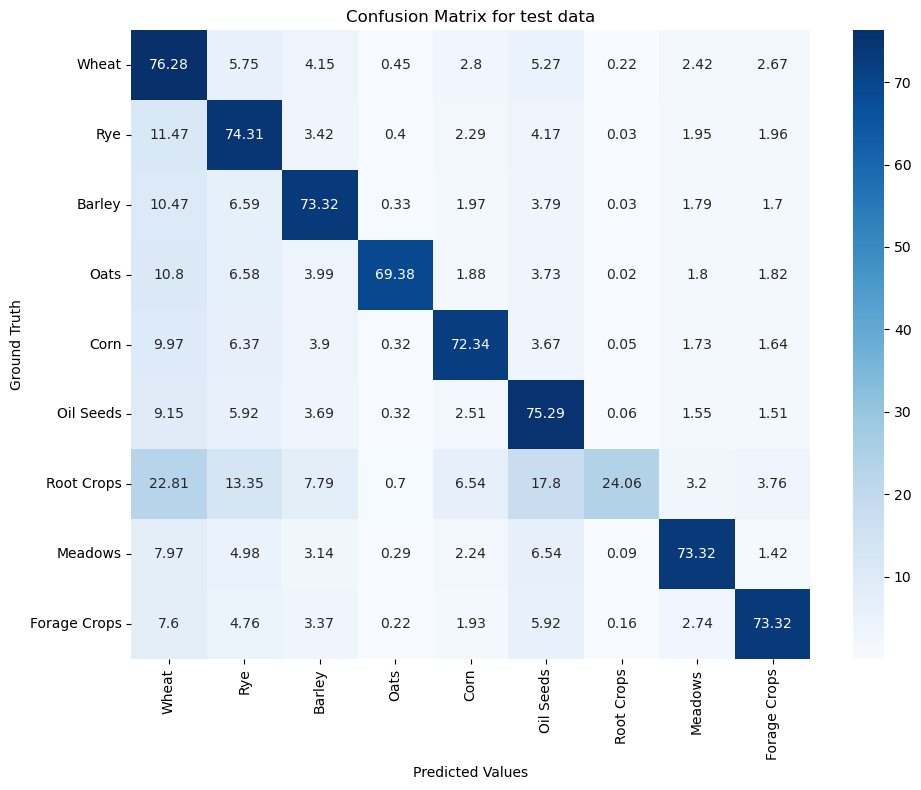

In [ ]:
C = pd.DataFrame(results["confusion_matrix"])
C = C.div(C.sum(axis=1), axis=0).mul(100).round(2)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    C, annot=True, fmt="g", cmap="Blues",
    xticklabels=CROP_CLASSES[1:], yticklabels=CROP_CLASSES[1:], ax=ax
)
ax.set_title("Confusion Matrix for test data")
ax.set_xlabel("Predicted Values")
ax.set_ylabel("Ground Truth")
ax.tick_params(axis='x', labelrotation=90)
plt.tight_layout()
plt.show()